# Modelo Cox para Análise de Falhas em Manutenção

Este notebook implementa um modelo Cox adaptado para a realidade de dados de manutenção:
- Eventos de falha (manutenção preventiva e corretiva)
- Características do equipamento (marca, modelo)
- Tipo e gravidade do problema (para manutenções corretivas)


In [1]:
# Imports necessários
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.utils import concordance_index

# Configurações
np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
print("Setup completo!")


Setup completo!


## 1. Gerando Dados Sintéticos de Manutenção

Vamos simular dados que refletem sua realidade:
- Ar-condicionados de diferentes marcas e modelos
- Falhas com tipos específicos e gravidades
- Manutenções preventivas e corretivas


In [10]:
# Simular dados de manutenção de ar-condicionado
n_equipamentos = 500

# Características dos equipamentos
marcas = ['Samsung', 'LG', 'Carrier', 'Midea', 'Consul']
modelos = ['9000BTU', '12000BTU', '18000BTU', '24000BTU']

# Tipos de problemas para manutenção corretiva
# Cada tipo de problema tem sua probabilidade de ocorrência e distribuição de gravidade
tipos_problema = {
    'pingando': {
        'prob': 0.3, 
        'gravidade_dist': {'baixa': 0.6, 'media': 0.3, 'alta': 0.1}
    },
    'não_liga': {
        'prob': 0.2, 
        'gravidade_dist': {'baixa': 0.1, 'media': 0.3, 'alta': 0.6}
    },
    'não_gela': {
        'prob': 0.25, 
        'gravidade_dist': {'baixa': 0.2, 'media': 0.5, 'alta': 0.3}
    },
    'barulho': {
        'prob': 0.15, 
        'gravidade_dist': {'baixa': 0.7, 'media': 0.2, 'alta': 0.1}
    },
    'vazamento_gas': {
        'prob': 0.1, 
        'gravidade_dist': {'baixa': 0.0, 'media': 0.2, 'alta': 0.8}
    }
}

# Gerar histórico de manutenções
dados = []

for equip_id in range(1, n_equipamentos + 1):
    # Características do equipamento
    marca = np.random.choice(marcas)
    modelo = np.random.choice(modelos)
    
    # Data de instalação
    data_instalacao = datetime(2020, 1, 1) + timedelta(days=np.random.randint(0, 365*2))
    
    # Fatores de risco baseados nas características do equipamento
    # Marcas com diferentes confiabilidades
    risco_marca = {
        'Samsung': 0.8, 
        'LG': 0.9, 
        'Carrier': 1.0, 
        'Midea': 1.2, 
        'Consul': 1.1
    }[marca]
    
    # Modelos maiores têm mais risco
    risco_modelo = {
        '9000BTU': 0.9, 
        '12000BTU': 1.0, 
        '18000BTU': 1.1, 
        '24000BTU': 1.3
    }[modelo]
    
    # Gerar eventos de manutenção
    data_atual = data_instalacao
    n_eventos = np.random.randint(1, 6)  # 1 a 5 eventos por equipamento
    
    for evento_num in range(n_eventos):
        # Tempo até próxima falha (influenciado pelos fatores de risco do equipamento)
        tempo_base = np.random.exponential(365)  # Média de 1 ano
        tempo_ate_falha = tempo_base / (risco_marca * risco_modelo)
        
        # Data do evento
        data_evento = data_atual + timedelta(days=int(tempo_ate_falha))
        
        # Tipo de manutenção (70% corretiva, 30% preventiva)
        if np.random.random() < 0.7:
            tipo_manutencao = 'corretiva'
            
            # Selecionar tipo de problema baseado nas probabilidades
            probs = [tipos_problema[tp]['prob'] for tp in tipos_problema]
            tipo_problema = np.random.choice(list(tipos_problema.keys()), p=probs)
            
            # Gravidade determinada pelo tipo de problema que ocorreu
            gravidades = list(tipos_problema[tipo_problema]['gravidade_dist'].keys())
            prob_gravidades = list(tipos_problema[tipo_problema]['gravidade_dist'].values())
            gravidade = np.random.choice(gravidades, p=prob_gravidades)
        else:
            tipo_manutencao = 'preventiva'
            tipo_problema = None
            gravidade = None  # Manutenção preventiva não tem problema/gravidade
        
        # Adicionar evento
        dados.append({
            'equipment_id': equip_id,
            'marca': marca,
            'modelo': modelo,
            'data_instalacao': data_instalacao,
            'data_evento': data_evento,
            'tipo_manutencao': tipo_manutencao,
            'tipo_problema': tipo_problema,
            'gravidade_problema': gravidade,  # Renomeado para deixar claro que é da falha
            'tempo_ate_falha_dias': (data_evento - data_atual).days
        })
        
        # Atualizar data atual
        data_atual = data_evento
        
        # Parar se passou de 2024
        if data_evento.year > 2024:
            break

# Criar DataFrame
df_manutencao = pd.DataFrame(dados)

print(f"Dataset criado com {len(df_manutencao)} eventos de manutenção")
print(f"Equipamentos únicos: {df_manutencao['equipment_id'].nunique()}")
print(f"\nDistribuição de tipos de manutenção:")
print(df_manutencao['tipo_manutencao'].value_counts())

# Mostrar distribuição de problemas e gravidades
print(f"\nDistribuição de tipos de problema:")
print(df_manutencao[df_manutencao['tipo_manutencao'] == 'corretiva']['tipo_problema'].value_counts())

print(f"\nDistribuição de gravidade por tipo de problema:")
for problema in tipos_problema.keys():
    df_problema = df_manutencao[df_manutencao['tipo_problema'] == problema]
    if len(df_problema) > 0:
        print(f"\n{problema}:")
        print(df_problema['gravidade_problema'].value_counts(normalize=True).round(3))

print(f"\nPrimeiras linhas:")
print(df_manutencao.head(10))

Dataset criado com 1357 eventos de manutenção
Equipamentos únicos: 500

Distribuição de tipos de manutenção:
tipo_manutencao
corretiva     938
preventiva    419
Name: count, dtype: int64

Distribuição de tipos de problema:
tipo_problema
pingando         299
não_gela         229
não_liga         196
barulho          134
vazamento_gas     80
Name: count, dtype: int64

Distribuição de gravidade por tipo de problema:

pingando:
gravidade_problema
baixa    0.579
media    0.341
alta     0.080
Name: proportion, dtype: float64

não_liga:
gravidade_problema
alta     0.602
media    0.306
baixa    0.092
Name: proportion, dtype: float64

não_gela:
gravidade_problema
media    0.480
alta     0.323
baixa    0.197
Name: proportion, dtype: float64

barulho:
gravidade_problema
baixa    0.664
media    0.224
alta     0.112
Name: proportion, dtype: float64

vazamento_gas:
gravidade_problema
alta     0.775
media    0.225
Name: proportion, dtype: float64

Primeiras linhas:
   equipment_id   marca    modelo d

## 2. Preparação dos Dados para o Modelo Cox

Para usar o modelo Cox, precisamos:
1. Definir o tempo até o evento (falha)
2. Indicar se houve falha ou censura
3. Preparar as covariáveis (características)


In [12]:
# Filtrar apenas manutenções corretivas (falhas reais)
df_falhas = df_manutencao[df_manutencao['tipo_manutencao'] == 'corretiva'].copy()

# Para cada equipamento, calcular tempos entre falhas
df_cox = []

for equip_id in df_falhas['equipment_id'].unique():
    eventos_equip = df_falhas[df_falhas['equipment_id'] == equip_id].sort_values('data_evento')
    
    if len(eventos_equip) > 0:
        # Primeira falha
        primeira_falha = eventos_equip.iloc[0]
        tempo_ate_primeira = (primeira_falha['data_evento'] - primeira_falha['data_instalacao']).days
        
        df_cox.append({
            'equipment_id': equip_id,
            'marca': primeira_falha['marca'],
            'modelo': primeira_falha['modelo'],
            'tempo_dias': tempo_ate_primeira,
            'evento': 1,  # Sempre 1 pois são falhas observadas
            'tipo_problema': primeira_falha['tipo_problema'],
            'gravidade_problema': primeira_falha['gravidade_problema'],  # Nome atualizado
            'ciclo': 1
        })
        
        # Falhas subsequentes
        for i in range(1, len(eventos_equip)):
            tempo_entre = (eventos_equip.iloc[i]['data_evento'] - 
                          eventos_equip.iloc[i-1]['data_evento']).days
            
            df_cox.append({
                'equipment_id': equip_id,
                'marca': eventos_equip.iloc[i]['marca'],
                'modelo': eventos_equip.iloc[i]['modelo'],
                'tempo_dias': tempo_entre,
                'evento': 1,
                'tipo_problema': eventos_equip.iloc[i]['tipo_problema'],
                'gravidade_problema': eventos_equip.iloc[i]['gravidade_problema'],  # Nome atualizado
                'ciclo': i + 1
            })

# Adicionar equipamentos sem falhas (censurados)
equips_sem_falha = set(df_manutencao['equipment_id'].unique()) - set(df_falhas['equipment_id'].unique())

for equip_id in equips_sem_falha:
    info_equip = df_manutencao[df_manutencao['equipment_id'] == equip_id].iloc[0]
    tempo_observacao = (datetime(2024, 12, 31) - info_equip['data_instalacao']).days
    
    df_cox.append({
        'equipment_id': equip_id,
        'marca': info_equip['marca'],
        'modelo': info_equip['modelo'],
        'tempo_dias': tempo_observacao,
        'evento': 0,  # Censurado
        'tipo_problema': None,  # Sem falha, então None ao invés de string
        'gravidade_problema': None,  # Sem falha, então None ao invés de string
        'ciclo': 0
    })

df_cox = pd.DataFrame(df_cox)

print(f"Dataset para Cox: {len(df_cox)} observações")
print(f"Taxa de eventos: {df_cox['evento'].mean():.1%}")

print(f"\nDistribuição por marca:")
print(df_cox['marca'].value_counts())

print(f"\nDistribuição por modelo:")
print(df_cox['modelo'].value_counts())

print(f"\nDistribuição de problemas (apenas falhas observadas):")
print(df_cox[df_cox['evento'] == 1]['tipo_problema'].value_counts())

print(f"\nDistribuição de gravidade por problema (apenas falhas observadas):")
for problema in tipos_problema.keys():
    df_problema = df_cox[(df_cox['tipo_problema'] == problema) & (df_cox['evento'] == 1)]
    if len(df_problema) > 0:
        print(f"\n{problema}:")
        print(df_problema['gravidade_problema'].value_counts())

print(f"\nEstatísticas de tempo até falha:")
print(df_cox[df_cox['evento'] == 1]['tempo_dias'].describe())

print(f"\nPrimeiras linhas:")
print(df_cox.head(10))

Dataset para Cox: 986 observações
Taxa de eventos: 95.1%

Distribuição por marca:
marca
Carrier    219
Samsung    213
Midea      202
Consul     193
LG         159
Name: count, dtype: int64

Distribuição por modelo:
modelo
9000BTU     259
12000BTU    256
24000BTU    240
18000BTU    231
Name: count, dtype: int64

Distribuição de problemas (apenas falhas observadas):
tipo_problema
pingando         299
não_gela         229
não_liga         196
barulho          134
vazamento_gas     80
Name: count, dtype: int64

Distribuição de gravidade por problema (apenas falhas observadas):

pingando:
gravidade_problema
baixa    173
media    102
alta      24
Name: count, dtype: int64

não_liga:
gravidade_problema
alta     118
media     60
baixa     18
Name: count, dtype: int64

não_gela:
gravidade_problema
media    110
alta      74
baixa     45
Name: count, dtype: int64

barulho:
gravidade_problema
baixa    89
media    30
alta     15
Name: count, dtype: int64

vazamento_gas:
gravidade_problema
alta     

## 3. Preparação das Variáveis para o Modelo


In [14]:
# Criar variáveis dummy para características categóricas
# Usar uma categoria de referência para cada variável
df_model = df_cox.copy()

# Para marca (referência: Samsung)
df_model = pd.get_dummies(df_model, columns=['marca'], prefix='marca', drop_first=True)

# Para modelo (referência: 9000BTU)
df_model = pd.get_dummies(df_model, columns=['modelo'], prefix='modelo', drop_first=True)

# Para tipo de problema
# Primeiro, precisamos tratar os valores None para criar dummies corretamente
df_model['tipo_problema'] = df_model['tipo_problema'].fillna('sem_falha')
df_model = pd.get_dummies(df_model, columns=['tipo_problema'], prefix='problema', drop_first=True)

# Para gravidade do problema
# Também tratamos os valores None
df_model['gravidade_problema'] = df_model['gravidade_problema'].fillna('sem_falha')
df_model = pd.get_dummies(df_model, columns=['gravidade_problema'], prefix='gravidade', drop_first=True)

# Adicionar ciclo normalizado como variável contínua
df_model['ciclo_norm'] = (df_model['ciclo'] - df_model['ciclo'].mean()) / df_model['ciclo'].std()

# Selecionar features para o modelo
feature_cols = [col for col in df_model.columns 
                if col.startswith(('marca_', 'modelo_', 'problema_', 'gravidade_', 'ciclo_norm'))]

print("Features do modelo:")
for feat in sorted(feature_cols):
    print(f"  - {feat}")
    
print(f"\nTotal de features: {len(feature_cols)}")

# Mostrar contagem de cada feature
print("\nDistribuição das features categóricas:")
for feat in sorted(feature_cols):
    if not feat.startswith('ciclo'):
        print(f"\n{feat}: {df_model[feat].sum()} ocorrências")

# Verificar se há valores ausentes
print(f"\nValores ausentes por coluna:")
print(df_model[feature_cols].isnull().sum())

Features do modelo:
  - ciclo_norm
  - gravidade_baixa
  - gravidade_media
  - gravidade_sem_falha
  - marca_Consul
  - marca_LG
  - marca_Midea
  - marca_Samsung
  - modelo_18000BTU
  - modelo_24000BTU
  - modelo_9000BTU
  - problema_não_gela
  - problema_não_liga
  - problema_pingando
  - problema_sem_falha
  - problema_vazamento_gas

Total de features: 16

Distribuição das features categóricas:

gravidade_baixa: 325 ocorrências

gravidade_media: 320 ocorrências

gravidade_sem_falha: 48 ocorrências

marca_Consul: 193 ocorrências

marca_LG: 159 ocorrências

marca_Midea: 202 ocorrências

marca_Samsung: 213 ocorrências

modelo_18000BTU: 231 ocorrências

modelo_24000BTU: 240 ocorrências

modelo_9000BTU: 259 ocorrências

problema_não_gela: 229 ocorrências

problema_não_liga: 196 ocorrências

problema_pingando: 299 ocorrências

problema_sem_falha: 48 ocorrências

problema_vazamento_gas: 80 ocorrências

Valores ausentes por coluna:
marca_Consul              0
marca_LG                  0
mar

## 4. Ajustando o Modelo Cox


In [15]:
# Criar e ajustar o modelo
cph = CoxPHFitter(penalizer=0.1)  # Pequena regularização

# Ajustar com todas as features
cph.fit(df_model[feature_cols + ['tempo_dias', 'evento']], 
        duration_col='tempo_dias', 
        event_col='evento')

# Mostrar resumo
print("MODELO COX - RESUMO")
print("=" * 70)
cph.print_summary(decimals=3)


MODELO COX - RESUMO


<lifelines.CoxPHFitter: fitted with 986 total observations, 48 right-censored observations>
             duration col = 'tempo_dias'
                event col = 'evento'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 986
number of events observed = 938
   partial log-likelihood = -5472.476
         time fit was run = 2025-10-18 21:23:38 UTC

---
                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                
marca_Consul            0.126     1.134     0.092          -0.055           0.307               0.946               1.359
marca_LG               -0.137     0.872     0.098          -0.329           0.056               0.719               1.058
marca_Midea             0.158     1.171     0.091          -0.020           0.336               0.980               1.399
marca_Samsung          -0.216     0.805     0.088          -0.389          -0.043               0.677               0.958
modelo_18000BTU         0.030     1.031     0.085          -0.137           0.197               0.872               1.218
modelo_24000BTU         0.383     1.467     0.085           0.217           0.550               1.242               1.733
modelo_9000BTU         -0.132     0.876     0.082          -0.293           0.030               0.746               1.030
problema_não_gela       0.155     1.168     0.097          -0.034           0.345               0.966               1.412
problema_não_liga       0.144     1.155     0.102          -0.056           0.344               0.945               1.410
problema_pingando      -0.015     0.986     0.089          -0.188           0.159               0.828               1.173
problema_sem_falha     -1.529     0.217     0.372          -2.258          -0.800               0.105               0.449
problema_vazamento_gas  0.058     1.059     0.135          -0.207           0.322               0.813               1.380
gravidade_baixa         0.007     1.007     0.087          -0.162           0.177               0.850               1.194
gravidade_media         0.030     1.030     0.079          -0.125           0.184               0.883               1.202
gravidade_sem_falha    -1.529     0.217     0.372          -2.258          -0.800               0.105               0.449
ciclo_norm              0.049     1.050     0.035          -0.020           0.117               0.980               1.124

                        cmp to      z       p  -log2(p)
covariate                                              
marca_Consul             0.000  1.362   0.173     2.529
marca_LG                 0.000 -1.387   0.165     2.596
marca_Midea              0.000  1.737   0.082     3.600
marca_Samsung            0.000 -2.450   0.014     6.131
modelo_18000BTU          0.000  0.355   0.722     0.469
modelo_24000BTU          0.000  4.517 <0.0005    17.280
modelo_9000BTU           0.000 -1.600   0.110     3.191
problema_não_gela        0.000  1.604   0.109     3.203
problema_não_liga        0.000  1.410   0.159     2.656
problema_pingando        0.000 -0.164   0.869     0.202
problema_sem_falha       0.000 -4.111 <0.0005    14.630
problema_vazamento_gas   0.000  0.427   0.670     0.579
gravidade_baixa          0.000  0.085   0.933     0.101
gravidade_media          0.000  0.379   0.705     0.505
gravidade_sem_falha      0.000 -4.111 <0.0005    14.630
ciclo_norm               0.000  1.389   0.165     2.601
---
Concordance = 0.615
Partial AIC = 10976.952
log-likelihood ratio test = 305.910 on 16 df
-log2(p) of ll-ratio test = 182.101

## 5. Interpretação dos Resultados

Vamos extrair insights práticos do modelo:


FATORES DE RISCO SIGNIFICATIVOS (p < 0.05)

marca_Samsung:
  - Reduz o risco de falha em 19.5%
  - Hazard Ratio: 0.81

modelo_24000BTU:
  - Aumenta o risco de falha em 46.7%
  - Hazard Ratio: 1.47

problema_sem_falha:
  - Reduz o risco de falha em 78.3%
  - Hazard Ratio: 0.22

gravidade_sem_falha:
  - Reduz o risco de falha em 78.3%
  - Hazard Ratio: 0.22


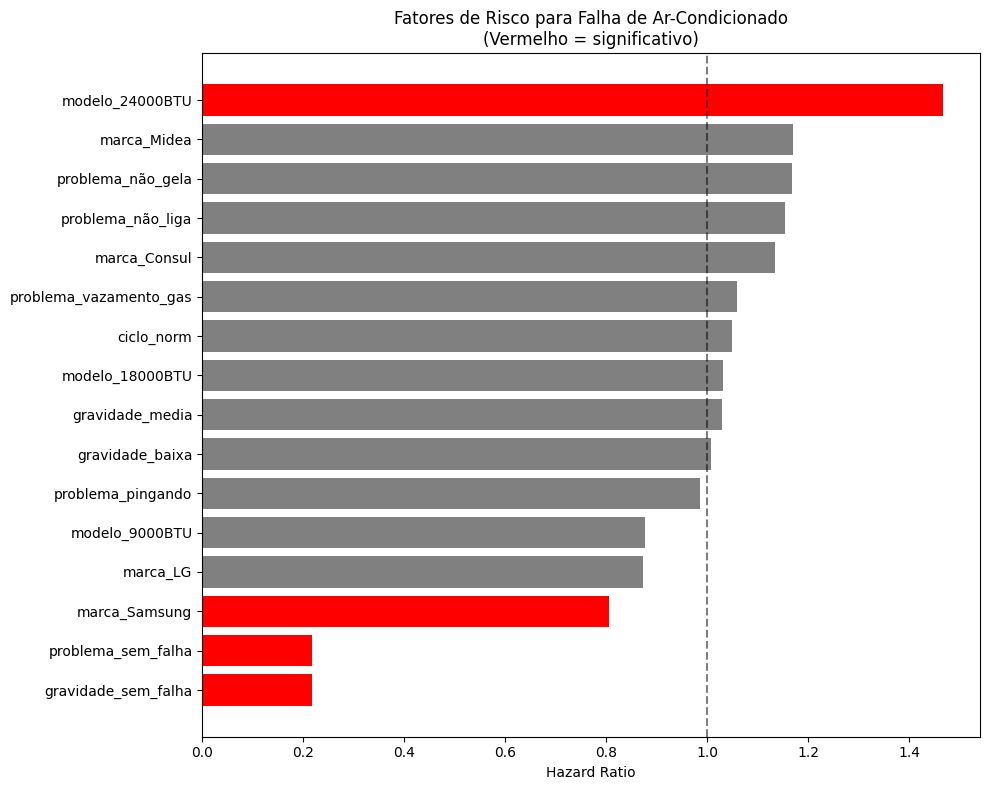

In [16]:
# Extrair resultados significativos
resultados_sig = cph.summary[cph.summary['p'] < 0.05].copy()
resultados_sig['HR'] = np.exp(resultados_sig['coef'])
resultados_sig['impacto_%'] = (resultados_sig['HR'] - 1) * 100

print("FATORES DE RISCO SIGNIFICATIVOS (p < 0.05)")
print("=" * 70)

for idx, row in resultados_sig.iterrows():
    hr = row['HR']
    impacto = row['impacto_%']
    
    if hr > 1:
        print(f"\n{idx}:")
        print(f"  - Aumenta o risco de falha em {impacto:.1f}%")
        print(f"  - Hazard Ratio: {hr:.2f}")
    else:
        print(f"\n{idx}:")
        print(f"  - Reduz o risco de falha em {-impacto:.1f}%")
        print(f"  - Hazard Ratio: {hr:.2f}")

# Visualizar os hazard ratios
plt.figure(figsize=(10, 8))

# Ordenar por HR
hr_data = pd.DataFrame({
    'variavel': cph.params_.index,
    'HR': np.exp(cph.params_),
    'p_value': cph.summary['p']
})
hr_data = hr_data.sort_values('HR')

# Cores baseadas na significância
colors = ['red' if p < 0.05 else 'gray' for p in hr_data['p_value']]

# Plot
y_pos = np.arange(len(hr_data))
plt.barh(y_pos, hr_data['HR'], color=colors)
plt.yticks(y_pos, hr_data['variavel'])
plt.xlabel('Hazard Ratio')
plt.title('Fatores de Risco para Falha de Ar-Condicionado\n(Vermelho = significativo)')
plt.axvline(1, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 6. Análise por Tipo de Problema


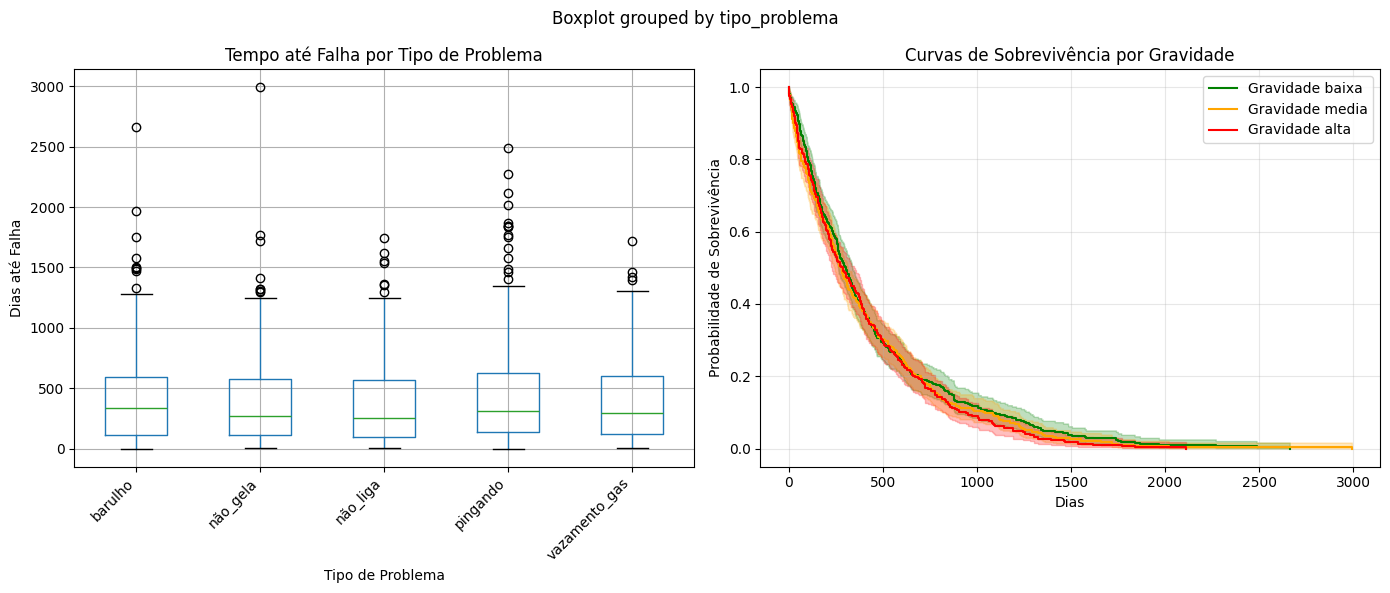


ESTATÍSTICAS POR TIPO DE PROBLEMA:
               Média (dias)  Mediana (dias)  Desvio Padrão  N casos
tipo_problema                                                      
barulho               448.4           335.0          455.5      134
não_gela              389.4           266.0          390.6      229
não_liga              385.3           255.5          372.6      196
pingando              456.4           308.0          460.5      299
vazamento_gas         421.7           292.0          409.1       80


ESTATÍSTICAS POR GRAVIDADE:
                    Média (dias)  Mediana (dias)  Desvio Padrão  N casos
gravidade_problema                                                      
alta                       403.0           287.0          382.3      293
baixa                      443.6           304.0          450.9      325
media                      414.7           283.0          426.3      320


DISTRIBUIÇÃO: TIPO DE PROBLEMA vs GRAVIDADE:
gravidade_problema  alta  baixa  media  Total


In [18]:
# Analisar tempo até falha por tipo de problema
# Filtrar apenas registros com falhas reais (evento == 1 ou tipo_problema não é None)
df_problemas = df_cox[df_cox['evento'] == 1].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Box plot por tipo de problema
df_problemas.boxplot(column='tempo_dias', by='tipo_problema', ax=ax1)
ax1.set_xlabel('Tipo de Problema')
ax1.set_ylabel('Dias até Falha')
ax1.set_title('Tempo até Falha por Tipo de Problema')
plt.sca(ax1)
plt.xticks(rotation=45, ha='right')

# Kaplan-Meier por gravidade
kmf = KaplanMeierFitter()
gravidades = ['baixa', 'media', 'alta']
cores = ['green', 'orange', 'red']

for grav, cor in zip(gravidades, cores):
    mask = df_problemas['gravidade_problema'] == grav  # Nome atualizado
    if mask.sum() > 0:
        kmf.fit(df_problemas.loc[mask, 'tempo_dias'], 
                df_problemas.loc[mask, 'evento'], 
                label=f'Gravidade {grav}')
        kmf.plot_survival_function(ax=ax2, color=cor)

ax2.set_xlabel('Dias')
ax2.set_ylabel('Probabilidade de Sobrevivência')
ax2.set_title('Curvas de Sobrevivência por Gravidade')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estatísticas por tipo de problema
print("\nESTATÍSTICAS POR TIPO DE PROBLEMA:")
print("=" * 50)
stats_problema = df_problemas.groupby('tipo_problema')['tempo_dias'].agg(['mean', 'median', 'std', 'count'])
stats_problema.columns = ['Média (dias)', 'Mediana (dias)', 'Desvio Padrão', 'N casos']
print(stats_problema.round(1))

# Estatísticas por gravidade
print("\n\nESTATÍSTICAS POR GRAVIDADE:")
print("=" * 50)
stats_gravidade = df_problemas.groupby('gravidade_problema')['tempo_dias'].agg(['mean', 'median', 'std', 'count'])
stats_gravidade.columns = ['Média (dias)', 'Mediana (dias)', 'Desvio Padrão', 'N casos']
print(stats_gravidade.round(1))

# Tabela cruzada: tipo de problema vs gravidade
print("\n\nDISTRIBUIÇÃO: TIPO DE PROBLEMA vs GRAVIDADE:")
print("=" * 50)
crosstab = pd.crosstab(df_problemas['tipo_problema'], 
                       df_problemas['gravidade_problema'], 
                       margins=True, 
                       margins_name='Total')
print(crosstab)

# Tempo médio até falha por tipo de problema E gravidade
print("\n\nTEMPO MÉDIO ATÉ FALHA (dias) - PROBLEMA vs GRAVIDADE:")
print("=" * 50)
pivot_tempo = df_problemas.pivot_table(values='tempo_dias', 
                                        index='tipo_problema', 
                                        columns='gravidade_problema', 
                                        aggfunc='mean')
print(pivot_tempo.round(1))

## 7. Predição para Novos Equipamentos


Features usadas para predição:
Total de features: 16

Features de equipamento:
  - ciclo_norm
  - marca_Consul
  - marca_LG
  - marca_Midea
  - marca_Samsung
  - modelo_18000BTU
  - modelo_24000BTU
  - modelo_9000BTU

Features de problema/gravidade (zeradas para predição):
  - gravidade_baixa
  - gravidade_media
  - gravidade_sem_falha
  - problema_não_gela
  - problema_não_liga
  - problema_pingando
  - problema_sem_falha
  - problema_vazamento_gas

PREDIÇÃO DE RISCO PARA DIFERENTES EQUIPAMENTOS

Samsung 9000BTU - Novo:
  - Tempo mediano até falha: 364 dias (1.0 anos)
  - Probabilidade de falha em 180 dias (0.5 anos): 29.2%
  - Probabilidade de falha em 365 dias (1.0 anos): 50.0%
  - Probabilidade de falha em 730 dias (2.0 anos): 75.3%

Midea 24000BTU - Novo:
  - Tempo mediano até falha: 221 dias (0.6 anos)
  - Probabilidade de falha em 180 dias (0.5 anos): 44.8%
  - Probabilidade de falha em 365 dias (1.0 anos): 69.6%
  - Probabilidade de falha em 730 dias (2.0 anos): 90.9%

LG 12000

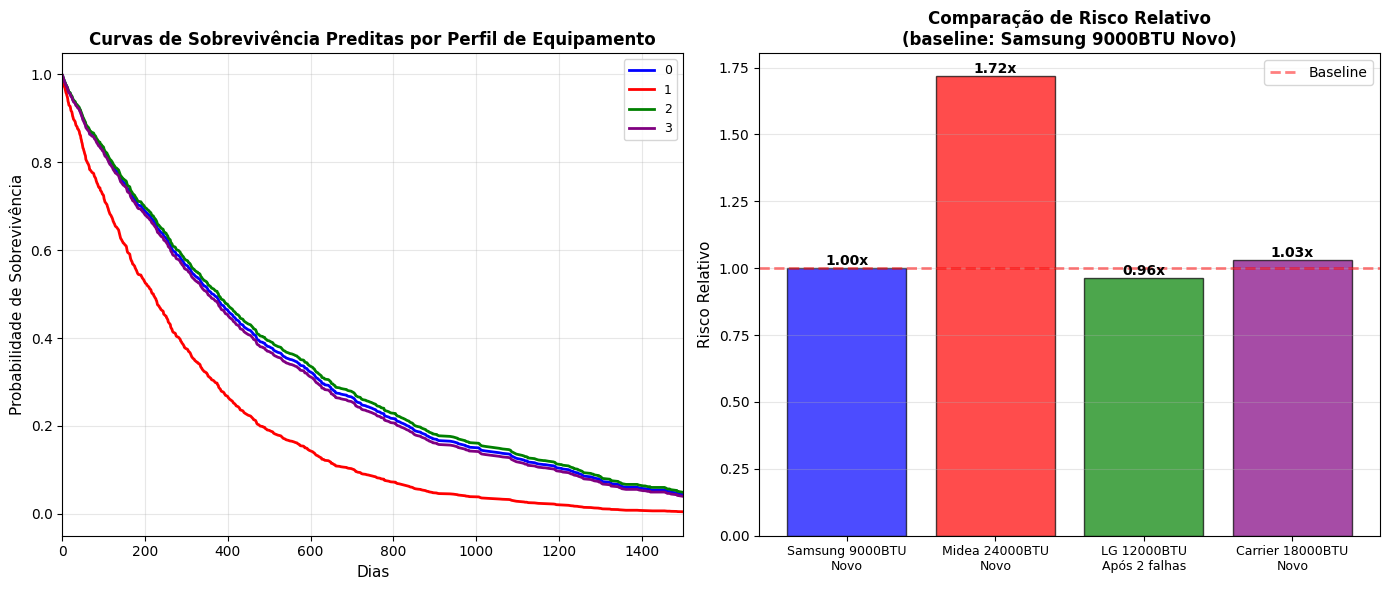


RESUMO COMPARATIVO:
                Equipamento Risco Relativo  Tempo Mediano (dias)  Tempo Mediano (anos)
     Samsung 9000BTU - Novo          1.00x                 364.0              0.997260
      Midea 24000BTU - Novo          1.72x                 221.0              0.605479
LG 12000BTU - Após 2 falhas          0.96x                 378.0              1.035616
    Carrier 18000BTU - Novo          1.03x                 352.0              0.964384


In [21]:
# Exemplo: prever risco para diferentes perfis de equipamento
# Criar perfis de exemplo
perfis = [
    {'nome': 'Samsung 9000BTU - Novo', 'marca': 'Samsung', 'modelo': '9000BTU', 'ciclo': 0},
    {'nome': 'Midea 24000BTU - Novo', 'marca': 'Midea', 'modelo': '24000BTU', 'ciclo': 0},
    {'nome': 'LG 12000BTU - Após 2 falhas', 'marca': 'LG', 'modelo': '12000BTU', 'ciclo': 2},
    {'nome': 'Carrier 18000BTU - Novo', 'marca': 'Carrier', 'modelo': '18000BTU', 'ciclo': 0}
]

# Preparar dados para predição
df_pred = pd.DataFrame(perfis)

# Criar TODAS as variáveis dummy consistentes com o modelo (incluindo problema e gravidade)
# Inicializar todas as features com 0
for col in feature_cols:
    if col == 'ciclo_norm':
        df_pred[col] = 0.0  # Inicializar como float
    else:
        df_pred[col] = 0

# Preencher valores apropriados
for idx, perfil in enumerate(perfis):
    # Marca (Samsung é referência - drop_first=True)
    if perfil['marca'] != 'Samsung':
        col_marca = f"marca_{perfil['marca']}"
        if col_marca in df_pred.columns:
            df_pred.loc[idx, col_marca] = 1
    
    # Modelo (9000BTU é referência - drop_first=True)
    if perfil['modelo'] != '9000BTU':
        col_modelo = f"modelo_{perfil['modelo']}"
        if col_modelo in df_pred.columns:
            df_pred.loc[idx, col_modelo] = 1
    
    # Ciclo normalizado usando as mesmas estatísticas do dataset de treino
    df_pred.loc[idx, 'ciclo_norm'] = (perfil['ciclo'] - df_model['ciclo'].mean()) / df_model['ciclo'].std()

# Para predição de equipamentos novos/sem falha ainda:
# - problema_* ficam todos em 0 (categoria de referência)
# - gravidade_* ficam todos em 0 (categoria de referência)
# Isso representa um equipamento "médio" sem histórico de problemas específicos

print("Features usadas para predição:")
print(f"Total de features: {len(feature_cols)}")
print("\nFeatures de equipamento:")
for feat in sorted([f for f in feature_cols if f.startswith(('marca_', 'modelo_', 'ciclo'))]):
    print(f"  - {feat}")
print("\nFeatures de problema/gravidade (zeradas para predição):")
for feat in sorted([f for f in feature_cols if f.startswith(('problema_', 'gravidade_'))]):
    print(f"  - {feat}")

# Fazer predições
print("\n" + "="*70)
print("PREDIÇÃO DE RISCO PARA DIFERENTES EQUIPAMENTOS")
print("="*70)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Calcular e plotar curvas de sobrevivência
cores = ['blue', 'red', 'green', 'purple']

for idx, (perfil, cor) in enumerate(zip(perfis, cores)):
    # Predizer curva de sobrevivência usando TODAS as features
    surv = cph.predict_survival_function(df_pred[feature_cols].iloc[[idx]])
    
    # Plotar
    surv.plot(ax=ax1, label=perfil['nome'], color=cor, linewidth=2)
    
    # Calcular métricas
    median_time = cph.predict_median(df_pred[feature_cols].iloc[[idx]])
    if hasattr(median_time, 'values'):
        median_value = median_time.values[0]
    else:
        median_value = float(median_time)
    
    # Probabilidade de falha em diferentes períodos
    periodos = [180, 365, 730]  # 6 meses, 1 ano, 2 anos
    
    print(f"\n{perfil['nome']}:")
    print(f"  - Tempo mediano até falha: {median_value:.0f} dias ({median_value/365:.1f} anos)")
    
    for dias in periodos:
        if dias in surv.index:
            prob_falha = 1 - surv.loc[dias].values[0]
        else:
            # Interpolação se o dia exato não existe
            idx_menor = surv.index[surv.index <= dias].max() if any(surv.index <= dias) else surv.index[0]
            prob_falha = 1 - surv.loc[idx_menor].values[0]
        print(f"  - Probabilidade de falha em {dias} dias ({dias/365:.1f} anos): {prob_falha:.1%}")

ax1.set_xlabel('Dias', fontsize=11)
ax1.set_ylabel('Probabilidade de Sobrevivência', fontsize=11)
ax1.set_title('Curvas de Sobrevivência Preditas por Perfil de Equipamento', fontsize=12, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 1500)  # Limitar a 1500 dias para melhor visualização

# Comparar hazard ratios
hazards = []
for idx, perfil in enumerate(perfis):
    hazard = cph.predict_partial_hazard(df_pred[feature_cols].iloc[[idx]]).values[0]
    hazards.append(hazard)

# Normalizar pelo primeiro perfil (baseline)
hazards_relativos = [h/hazards[0] for h in hazards]

bars = ax2.bar(range(len(perfis)), hazards_relativos, color=cores, alpha=0.7, edgecolor='black')
ax2.set_xticks(range(len(perfis)))
ax2.set_xticklabels([p['nome'].replace(' - ', '\n') for p in perfis], 
                     rotation=0, ha='center', fontsize=9)
ax2.set_ylabel('Risco Relativo', fontsize=11)
ax2.set_title('Comparação de Risco Relativo\n(baseline: Samsung 9000BTU Novo)', 
              fontsize=12, fontweight='bold')
ax2.axhline(1, color='red', linestyle='--', alpha=0.5, linewidth=2, label='Baseline')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for bar, hazard in zip(bars, hazards_relativos):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{hazard:.2f}x',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Resumo estatístico
print("\n" + "="*70)
print("RESUMO COMPARATIVO:")
print("="*70)
resumo_data = []
for i in range(len(perfis)):
    median = cph.predict_median(df_pred[feature_cols].iloc[[i]])
    if hasattr(median, 'values'):
        median_value = median.values[0]
    else:
        median_value = float(median)
    
    resumo_data.append({
        'Equipamento': perfis[i]['nome'],
        'Risco Relativo': f"{hazards_relativos[i]:.2f}x",
        'Tempo Mediano (dias)': median_value,
        'Tempo Mediano (anos)': median_value / 365
    })

resumo = pd.DataFrame(resumo_data)
print(resumo.to_string(index=False))

## 8. Recomendações Práticas

Com base no modelo, podemos extrair recomendações para manutenção:


In [23]:
print("RECOMENDAÇÕES BASEADAS NO MODELO")
print("=" * 70)

# 1. Marcas de maior risco
marcas_risco = []
for col in feature_cols:
    if col.startswith('marca_'):
        marca = col.replace('marca_', '')
        if col in cph.params_.index:
            hr = np.exp(cph.params_[col])
            p_value = cph.summary.loc[col, 'p']
            if p_value < 0.05 and hr > 1.2:
                marcas_risco.append((marca, hr, p_value))

if marcas_risco:
    print("\n1. MARCAS DE ALTO RISCO (comparado à Samsung - referência):")
    for marca, hr, p_val in sorted(marcas_risco, key=lambda x: x[1], reverse=True):
        print(f"   - {marca}: {(hr-1)*100:.0f}% mais risco (HR={hr:.2f}, p={p_val:.4f})")
else:
    print("\n1. MARCAS DE ALTO RISCO:")
    print("   - Nenhuma marca apresentou risco significativamente maior que Samsung")

# 2. Modelos problemáticos
modelos_risco = []
for col in feature_cols:
    if col.startswith('modelo_'):
        modelo = col.replace('modelo_', '')
        if col in cph.params_.index:
            hr = np.exp(cph.params_[col])
            p_value = cph.summary.loc[col, 'p']
            if p_value < 0.05 and hr > 1.2:
                modelos_risco.append((modelo, hr, p_value))

if modelos_risco:
    print("\n2. MODELOS DE ALTO RISCO (comparado ao 9000BTU - referência):")
    for modelo, hr, p_val in sorted(modelos_risco, key=lambda x: x[1], reverse=True):
        print(f"   - {modelo}: {(hr-1)*100:.0f}% mais risco (HR={hr:.2f}, p={p_val:.4f})")
else:
    print("\n2. MODELOS DE ALTO RISCO:")
    print("   - Nenhum modelo apresentou risco significativamente maior que 9000BTU")

# 3. Problemas mais graves
print("\n3. TIPOS DE PROBLEMA POR GRAVIDADE:")
problemas_graves = df_problemas[df_problemas['gravidade_problema'] == 'alta']['tipo_problema'].value_counts()

if len(problemas_graves) > 0:
    for problema, count in problemas_graves.items():
        total_problema = df_problemas[df_problemas['tipo_problema'] == problema].shape[0]
        if total_problema > 0:
            pct = count / total_problema * 100
            print(f"   - {problema}: {pct:.0f}% dos casos são de alta gravidade ({count}/{total_problema})")
else:
    print("   - Nenhum problema de alta gravidade registrado")

# Análise adicional: distribuição completa de gravidade por problema
print("\n   Distribuição completa de gravidade por tipo de problema:")
for problema in df_problemas['tipo_problema'].unique():
    df_prob = df_problemas[df_problemas['tipo_problema'] == problema]
    total = len(df_prob)
    if total > 0:
        print(f"\n   {problema} (n={total}):")
        for grav in ['baixa', 'media', 'alta']:
            count = (df_prob['gravidade_problema'] == grav).sum()
            pct = count / total * 100
            print(f"      - {grav}: {pct:.1f}% ({count} casos)")

# 4. Intervalo de manutenção recomendado
print("\n4. INTERVALOS DE MANUTENÇÃO PREVENTIVA SUGERIDOS:")
print("   (Baseado no percentil 25 do tempo até falha)")

for marca in ['Samsung', 'LG', 'Carrier', 'Midea', 'Consul']:
    # Filtrar apenas eventos com falha (evento=1)
    tempos_marca = df_cox[(df_cox['marca'] == marca) & (df_cox['evento'] == 1)]['tempo_dias']
    
    if len(tempos_marca) > 10:
        p25 = tempos_marca.quantile(0.25)
        media = tempos_marca.mean()
        print(f"   - {marca}: a cada {p25:.0f} dias (~{p25/30:.0f} meses) | média até falha: {media:.0f} dias")
    elif len(tempos_marca) > 0:
        media = tempos_marca.mean()
        print(f"   - {marca}: poucos dados (n={len(tempos_marca)}), média: {media:.0f} dias")
    else:
        print(f"   - {marca}: dados insuficientes")

# 5. Análise do impacto do ciclo de manutenções
if 'ciclo_norm' in cph.params_.index:
    hr_ciclo = np.exp(cph.params_['ciclo_norm'])
    p_ciclo = cph.summary.loc['ciclo_norm', 'p']
    print(f"\n5. IMPACTO DO HISTÓRICO DE MANUTENÇÕES:")
    if p_ciclo < 0.05:
        if hr_ciclo > 1:
            print(f"   - Equipamentos com mais falhas anteriores têm {(hr_ciclo-1)*100:.0f}% mais risco")
            print(f"     de nova falha (HR={hr_ciclo:.2f}, p={p_ciclo:.4f})")
            print(f"   - AÇÃO: Considere substituição após múltiplas falhas")
        else:
            print(f"   - Equipamentos com mais manutenções têm {(1-hr_ciclo)*100:.0f}% menos risco")
            print(f"     (HR={hr_ciclo:.2f}, p={p_ciclo:.4f})")
    else:
        print(f"   - Histórico de manutenções não tem impacto significativo (p={p_ciclo:.4f})")

# 6. Análise de problemas mais frequentes
print("\n6. PROBLEMAS MAIS FREQUENTES:")
freq_problemas = df_problemas['tipo_problema'].value_counts()
total_falhas = len(df_problemas)

for problema, count in freq_problemas.head(5).items():
    pct = count / total_falhas * 100
    # Tempo médio até esse tipo de falha
    tempo_medio = df_problemas[df_problemas['tipo_problema'] == problema]['tempo_dias'].mean()
    print(f"   - {problema}: {pct:.1f}% das falhas ({count} casos)")
    print(f"     Tempo médio até ocorrência: {tempo_medio:.0f} dias")

print("\n" + "=" * 70)
print("CONCLUSÃO E AÇÕES RECOMENDADAS:")
print("=" * 70)
print("\n✓ MANUTENÇÃO PREVENTIVA:")
print("  - Estabeleça intervalos baseados nos percentis 25 por marca")
print("  - Priorize equipamentos de alto risco (marcas/modelos identificados)")
print("  - Foque em equipamentos com múltiplas falhas anteriores")

print("\n✓ GESTÃO DE ESTOQUE:")
print("  - Mantenha peças para os problemas mais frequentes identificados")
print("  - Considere a gravidade típica de cada tipo de problema")

print("\n✓ POLÍTICA DE SUBSTITUIÇÃO:")
print("  - Avalie custo-benefício para equipamentos com múltiplas falhas")
print("  - Considere substituição proativa de modelos de alto risco")

print("\n✓ MONITORAMENTO:")
print("  - Acompanhe equipamentos próximos ao tempo médio de falha")
print("  - Dê atenção especial a problemas de alta gravidade")
print("=" * 70)

RECOMENDAÇÕES BASEADAS NO MODELO

1. MARCAS DE ALTO RISCO:
   - Nenhuma marca apresentou risco significativamente maior que Samsung

2. MODELOS DE ALTO RISCO (comparado ao 9000BTU - referência):
   - 24000BTU: 47% mais risco (HR=1.47, p=0.0000)

3. TIPOS DE PROBLEMA POR GRAVIDADE:
   - não_liga: 60% dos casos são de alta gravidade (118/196)
   - não_gela: 32% dos casos são de alta gravidade (74/229)
   - vazamento_gas: 78% dos casos são de alta gravidade (62/80)
   - pingando: 8% dos casos são de alta gravidade (24/299)
   - barulho: 11% dos casos são de alta gravidade (15/134)

   Distribuição completa de gravidade por tipo de problema:

   não_gela (n=229):
      - baixa: 19.7% (45 casos)
      - media: 48.0% (110 casos)
      - alta: 32.3% (74 casos)

   pingando (n=299):
      - baixa: 57.9% (173 casos)
      - media: 34.1% (102 casos)
      - alta: 8.0% (24 casos)

   não_liga (n=196):
      - baixa: 9.2% (18 casos)
      - media: 30.6% (60 casos)
      - alta: 60.2% (118 casos)

